In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Title

### Setting up and cleaning initial pandas dataframes

In [2]:
# Load the csv into a pandas database
netflix = pd.read_csv('netflix_titles.csv', keep_default_na=False)
netflix.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Remove director, cast, dated_added, and description columns 
# since we aren't going to be using them in our project.
netflix_cleaned = netflix.drop(columns=['director', 'cast', 'date_added', 'description'])
netflix_cleaned = netflix_cleaned[netflix_cleaned['country'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != 'NR']
netflix_cleaned.head(5)

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"


In [4]:
# Sub-database holding just movies
netflix_movies = netflix_cleaned[netflix_cleaned['type'] == 'Movie']
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,TV-MA,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [5]:
# Sub-database holding just tv shows
netflix_shows = netflix_cleaned[netflix_cleaned['type'] == 'TV Show']
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,TV-Y7,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,TV-Y7,3 Seasons,Kids' TV


### Sorting Data by Ratings for Visualization

In [6]:
ratings_movie = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR'
}

netflix_movies = netflix_movies.copy()
netflix_movies.loc[:, 'rating'] = (
    netflix_movies['rating']
    .str.strip()
    .str.upper()
    .map(ratings_movie)
    .fillna('UR')
)

netflix_movies_filtered = netflix_movies.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_movies_filtered

,release_year,rating,count
0,1942,PG-13,2
1,1943,PG,3
2,1944,PG,1
3,1944,PG-13,2
4,1945,PG-13,2
...,...,...,...
232,2020,R,250
233,2021,G,12
234,2021,PG,21
235,2021,PG-13,53


In [7]:
ratings_show = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR', 'NR': 'UR'
}

netflix_shows = netflix_shows.copy()
netflix_shows.loc[:, 'rating'] = (
    netflix_shows['rating']
    .fillna('UR')
    .astype(str)
    .str.strip()
    .str.upper()
    .map(ratings_show)
    .fillna('UR')
)

netflix_shows_filtered = netflix_shows.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_shows_filtered

,release_year,rating,count
0,1945,R,1
1,1946,PG-13,1
2,1963,PG-13,1
3,1967,G,1
4,1972,R,1
...,...,...,...
113,2020,R,233
114,2021,G,38
115,2021,PG,13
116,2021,PG-13,55


### Graphing Data

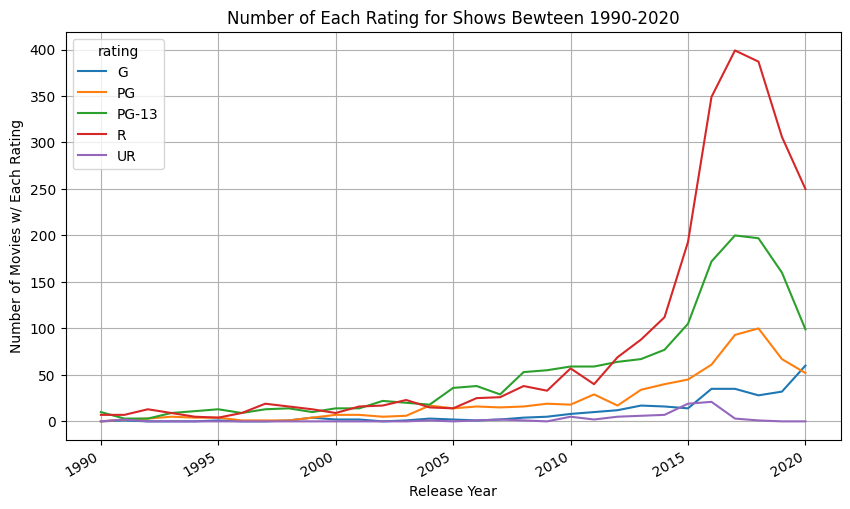

In [8]:
netflix_movies_agg = netflix_movies_filtered.groupby(['release_year', 'rating'])['count'].sum().reset_index()
pivoted_counts = netflix_movies_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

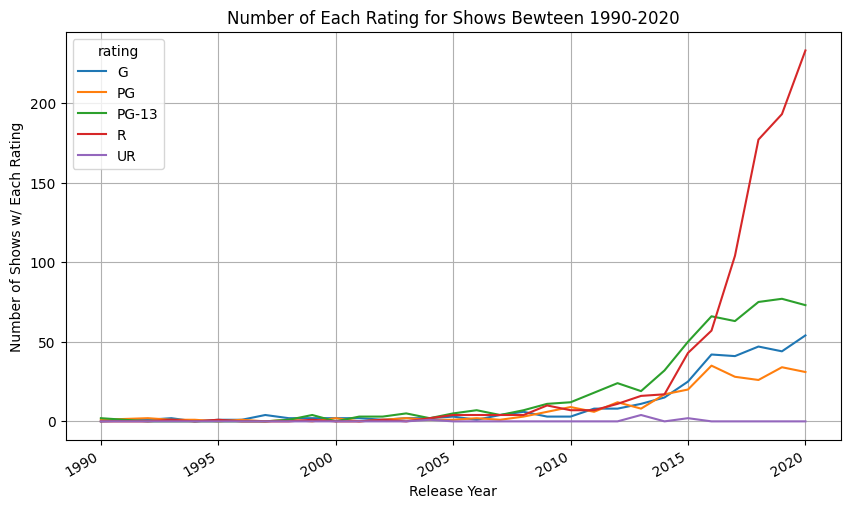

In [9]:
netflix_shows_agg = netflix_shows_filtered.groupby(['release_year', 'rating']).sum().reset_index()
pivoted_counts = netflix_shows_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

### Splitting up the 'listed_in' column for visualitation and future models

In [10]:
count = (
    netflix_movies['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
count

listed_in
International Movies        2543
Dramas                      2317
Comedies                    1580
Action & Adventure           817
Documentaries                794
Independent Movies           745
Romantic Movies              588
Thrillers                    549
Children & Family Movies     535
Horror Movies                340
Music & Musicals             328
Stand-Up Comedy              311
Sci-Fi & Fantasy             242
Sports Movies                201
Classic Movies               115
LGBTQ Movies                  97
Cult Movies                   70
Faith & Spirituality          63
Anime Features                63
Movies                        34
Name: count, dtype: int64

In [11]:
count = (
    netflix_shows['listed_in']
    .str.split(',')   # turn "apple,banana" → ['apple','banana']
    .explode()        # flatten
    .str.strip()      # remove spaces like " banana"
    .value_counts()   # count
)
count

listed_in
International TV Shows          1128
TV Dramas                        663
TV Comedies                      501
Crime TV Shows                   421
Kids' TV                         370
Docuseries                       330
Romantic TV Shows                299
British TV Shows                 237
Reality TV                       205
Anime Series                     154
TV Action & Adventure            153
Spanish-Language TV Shows        145
Korean TV Shows                  136
TV Mysteries                      92
Science & Nature TV               82
TV Sci-Fi & Fantasy               79
TV Horror                         72
Teen TV Shows                     66
TV Thrillers                      53
Stand-Up Comedy & Talk Shows      47
Classic & Cult TV                 27
TV Shows                           9
Name: count, dtype: int64

### Linear Regression

Question: Does the rating of a movie/show influence how long the duration of the movie/show is in time(shows = seasons, movie = minutes)?
- Using "rating" to predict "duration"

### Random Forest

Question: Is their a correlation between the rating of a movie and both its title and genre?
- Looking for rating using the "title" and "listed_in" columns of both movies and shows

In [12]:
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,R,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,R,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,PG-13,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,R,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,R,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,G,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,G,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,G,3 Seasons,Kids' TV


In [13]:
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,R,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,R,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,PG-13,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,R,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"
